In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("data.csv")
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df = df.drop(['id', 'Unnamed: 32'], axis=1)
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})

In [4]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [7]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Individual models
svm = SVC(probability=True)
rf = RandomForestClassifier(n_estimators=100)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Ensemble model
ensemble = VotingClassifier(
    estimators=[
        ('svm', svm),
        ('rf', rf),
        ('xgb', xgb)
    ],
    voting='soft'  # uses probability
)

ensemble.fit(X_train, y_train)

C:\Users\mcmh7\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:53:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,estimators,"[('svm', ...), ('rf', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0


In [8]:
y_pred = ensemble.predict(X_test)

In [9]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9649122807017544


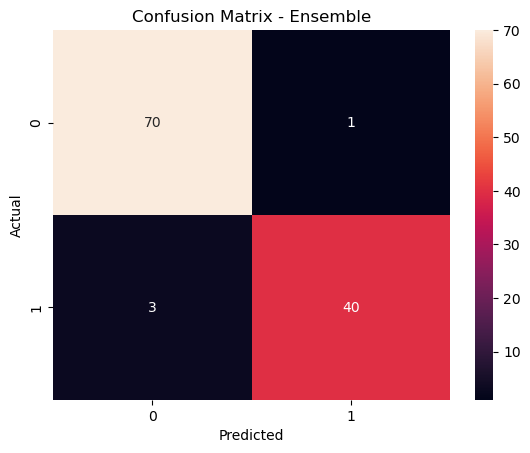

In [10]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Ensemble")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [12]:
# Instead of using input(), use this hardcoded list for testing
user_input = [
    17.99, 10.38, 122.8, 1001.0, 0.1184, 
    0.2776, 0.3001, 0.1471, 0.2419, 0.07871, 
    1.095, 0.9053, 8.589, 153.4, 0.006399, 
    0.04904, 0.05373, 0.01587, 0.03003, 0.006193, 
    25.38, 17.33, 184.6, 2019.0, 0.1622, 
    0.6656, 0.7119, 0.2654, 0.4601, 0.1189
]

# Now the rest of your code will run automatically without asking you for anything
input_df = pd.DataFrame([user_input], columns=X.columns)
input_scaled = scaler.transform(input_df)
prediction = ensemble.predict(input_scaled)

if prediction[0] == 1:
    print("⚠️ Cancer Detected (Malignant)")
else:
    print("✅ No Cancer (Benign)")

⚠️ Cancer Detected (Malignant)


In [13]:
if len(user_input) != 30:
    print("Please enter exactly 30 values")

In [26]:
import pickle

# Save the trained model
with open('ensemble.pkl', 'wb') as f:
    pickle.dump(ensemble, f)

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save the column names
with open('columns.pkl', 'wb') as f:
    pickle.dump(X.columns, f)

print("Files saved successfully!")

Files saved successfully!


In [19]:
import tensorflow as tf  # Make sure tensorflow is imported
print(tf.__version__)  # Use double underscores on both sides

2.21.0


In [23]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input # Changed Flatten to GlobalAveragePooling2D
from tensorflow.keras.models import Model

# 1. Define input shape
input_shape = (224, 224, 3)
input_tensor = Input(shape=input_shape)

# 2. Create the base model (Explicitly pass input_shape to remove the warning)
base_model = MobileNetV2(weights='imagenet', 
                         include_top=False, 
                         input_tensor=input_tensor,
                         input_shape=input_shape) # Added this

# 3. Freeze the base model so we don't destroy pre-trained weights
base_model.trainable = False

# 4. Build the head
x = GlobalAveragePooling2D()(base_model.output) # Better than Flatten() for CNNs
x = Dense(128, activation='relu')(x)
output = Dense(2, activation='softmax')(x)

# 5. Define and compile
model = Model(inputs=input_tensor, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [29]:
# After model.compile(...)
model.save("image_model.h5")  # Changed 'image_model' to 'model' to match the variable name

print("✅ Image model saved successfully!")

✅ Image model saved successfully!


In [2]:
import zipfile
import io
import os
import numpy as np
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt

# Load your saved image model
image_model = tf.keras.models.load_model('image_model.h5', compile=False)

def test_batch_zip_prediction(zip_path):
    print(f"Opening {zip_path}...")
    
    predictions = []
    body_parts_found = set()
    
    with zipfile.ZipFile(zip_path, 'r') as z:
        # Filter only image files
        valid_files = [f for f in z.infolist() if f.filename.lower().endswith(('.png', '.jpg', '.jpeg'))]
        total_images = len(valid_files)
        
        print(f"Total images found: {total_images}")
        
        for file_info in valid_files:
            # Try to guess body part from folder name (e.g., "lung_cancer_scans/img1.png")
            folder_name = os.path.dirname(file_info.filename).split('/')[0].lower()
            if folder_name:
                body_parts_found.add(folder_name)
                
            with z.open(file_info) as file:
                img = Image.open(file).convert('RGB')
                img_resized = img.resize((224, 224))
                img_array = np.array(img_resized)
                img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
                img_array = np.expand_dims(img_array, axis=0)
                
                preds = model.predict(img_array, verbose=0)[0]
                pred_class = np.argmax(preds)
                predictions.append(pred_class)
                
    malignant_count = sum(1 for p in predictions if p == 1)
    benign_count = total_images - malignant_count
    
    print(f"\n--- BATCH RESULTS ---")
    print(f"Inferred Body Parts/Categories: {', '.join(body_parts_found) if body_parts_found else 'Unknown'}")
    print(f"Malignant Cases: {malignant_count} ({(malignant_count/total_images)*100:.1f}%)")
    print(f"Benign Cases: {benign_count} ({(benign_count/total_images)*100:.1f}%)")

# To test this, simply call:
# test_batch_zip_prediction("path_to_your_test_file.zip")